In [4]:
import pandas as pd

In [5]:
df = pd.read_excel(r"C:\Users\jabbe\Downloads\DatasetGDPURFFRI.xlsx")

In [6]:
print(df)

          Date        GDP  UnemploymentRate  FederalFundsRate  Inflation
0   1959-01-01   3352.129          5.833333          2.570000   1.814459
1   1959-04-01   3427.667          5.100000          3.083333   1.918614
2   1959-07-01   3430.057          5.266667          3.576667   2.024752
3   1959-10-01   3439.832          5.600000          3.990000   2.125671
4   1960-01-01   3517.181          5.133333          3.933333   2.115942
..         ...        ...               ...               ...        ...
263 2024-10-01  23586.542          4.133333          4.650000   3.265986
264 2025-01-01  23548.210          4.133333          4.330000   3.076437
265 2025-04-01  23770.976          4.200000          4.330000   2.817585
266 2025-07-01  24026.834          4.333333          4.293333   3.062089
267 2025-10-01  24065.956          4.450000          3.896666   2.680914

[268 rows x 5 columns]


In [8]:
# This is the data for all of the available time period, but I only need the data relevant to the last head
# of the Federal Reserve, Jerome Powell.  He took office in February of 2018, so I will keep the quarterly
# data from April 2018 on.  

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# After changing the 'Date' column to be a date time column, let's filter out the Powell years, dfP.

In [12]:
dfP = df[df['Date'] > '2018-01-01']

In [13]:
print(dfP)

          Date           GDP  UnemploymentRate  FederalFundsRate  Inflation
237 2018-04-01  18507.088728          3.933333          1.736667   2.223053
238 2018-07-01  18576.449709          3.766667          1.923333   2.195390
239 2018-10-01  18645.810691          3.833333          2.220000   2.196774
240 2019-01-01  18715.171672          3.866667          2.403333   2.129028
241 2019-04-01  18784.532653          3.633333          2.396667   2.046122
242 2019-07-01  18853.893635          3.600000          2.190000   2.272284
243 2019-10-01  18923.254616          3.600000          1.643333   2.327703
244 2020-01-01  18992.615597          3.833333          1.260000   2.252615
245 2020-04-01  19061.976578         13.000000          0.060000   1.289013
246 2020-07-01  19131.337560          8.800000          0.093333   1.657156
247 2020-10-01  19200.698541          6.733333          0.090000   1.638214
248 2021-01-01  19270.059522          6.233333          0.080000   1.438948
249 2021-04-

In [14]:
# My ultimate goal is to find the training size that is necessary to make good predictions about future
# actions by the head of the Federal Reserve, so I'm going to set it to be easily changeable.  

In [16]:
train_size_ratio = 0.1
train_size = int(len(dfP) * train_size_ratio)

In [21]:
# I also don't want the training set to be random, I need it to be at the beginning, so I will set the size.

In [19]:
train_dfP = dfP.iloc[:train_size]
test_dfP = dfP.iloc[train_size:]

In [22]:
# Now make the training and test sets.  

In [23]:
X_trainP = train_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_trainP = train_dfP['FederalFundsRate']
X_testP = test_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_testP = test_dfP['FederalFundsRate']

In [26]:
# Set the model as a simple regression and fit the data.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [29]:
model = LinearRegression()
model.fit(X_trainP, y_trainP)

LinearRegression()

In [30]:
y_pred = model.predict(X_testP)
mse = mean_squared_error(y_testP, y_pred)

In [31]:
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("Mean Squared Error on test set:", mse)

Model coefficients: [0.00382979 0.46423393 0.0577925 ]
Model intercept: -71.09598957710496
Mean Squared Error on test set: 71.81068056606618


In [32]:
# Let's try a couple more values for train_size_ratio to see how these numbers are affected.

In [33]:
train_size_ratio = 0.2
train_size = int(len(dfP) * train_size_ratio)
train_dfP = dfP.iloc[:train_size]
test_dfP = dfP.iloc[train_size:]
X_trainP = train_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_trainP = train_dfP['FederalFundsRate']
X_testP = test_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_testP = test_dfP['FederalFundsRate']
model.fit(X_trainP, y_trainP)
y_pred = model.predict(X_testP)
mse = mean_squared_error(y_testP, y_pred)
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("Mean Squared Error on test set:", mse)

Model coefficients: [ 0.00234009  1.0885393  -1.49400283]
Model intercept: -42.42260482064126
Mean Squared Error on test set: 38.835030416118656


In [34]:
train_size_ratio = 0.3
train_size = int(len(dfP) * train_size_ratio)
train_dfP = dfP.iloc[:train_size]
test_dfP = dfP.iloc[train_size:]
X_trainP = train_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_trainP = train_dfP['FederalFundsRate']
X_testP = test_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_testP = test_dfP['FederalFundsRate']
model.fit(X_trainP, y_trainP)
y_pred = model.predict(X_testP)
mse = mean_squared_error(y_testP, y_pred)
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("Mean Squared Error on test set:", mse)

Model coefficients: [-4.93648030e-04 -4.94261502e-01 -3.05524627e+00]
Model intercept: 19.82421369026205
Mean Squared Error on test set: 77.89986219851275


In [35]:
train_size_ratio = 0.4
train_size = int(len(dfP) * train_size_ratio)
train_dfP = dfP.iloc[:train_size]
test_dfP = dfP.iloc[train_size:]
X_trainP = train_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_trainP = train_dfP['FederalFundsRate']
X_testP = test_dfP[['GDP', 'UnemploymentRate', 'Inflation']]
y_testP = test_dfP['FederalFundsRate']
model.fit(X_trainP, y_trainP)
y_pred = model.predict(X_testP)
mse = mean_squared_error(y_testP, y_pred)
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("Mean Squared Error on test set:", mse)

Model coefficients: [-0.00194555 -0.10645147  0.59818669]
Model intercept: 37.48546726800423
Mean Squared Error on test set: 45.56058429710796


In [1]:
# The train_size_ratio of 0.2 is the best, which is 6 periods (or 18 months).

In [38]:
gdp = dfP.GDP
ur  = dfP.UnemploymentRate
ffr = dfP.FederalFundsRate
i   = dfP.Inflation

In [41]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'Inflation')

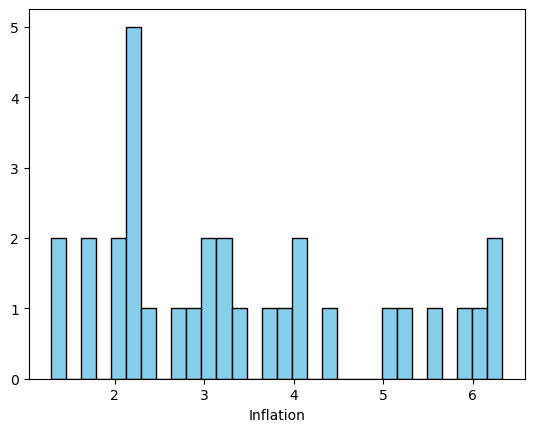

In [42]:
plt.hist(i, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Inflation')

Text(0.5, 0, 'Federal Funds Rate')

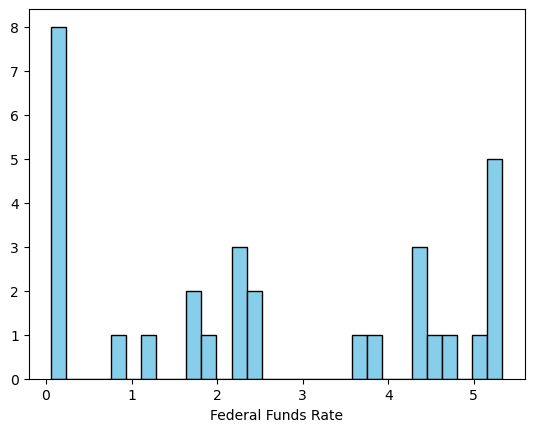

In [43]:
plt.hist(ffr, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Federal Funds Rate')

In [45]:
import thinkplot

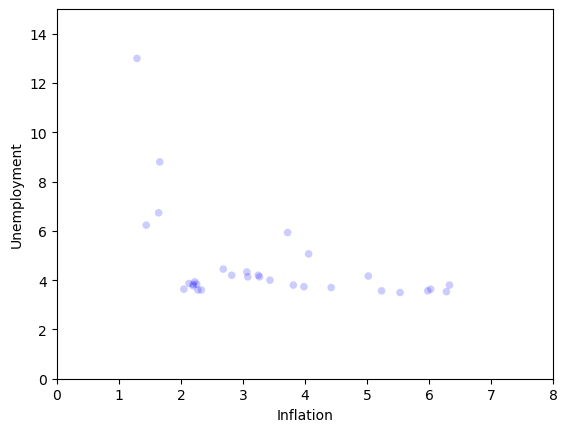

<Figure size 800x600 with 0 Axes>

In [49]:
thinkplot.Scatter(i, ur)
thinkplot.Show(xlabel = 'Inflation',
               ylabel = 'Unemployment',
               axis = [0,8,0,15])